In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv('df_model.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'df_model.csv'

In [ ]:

num_col = ['Age', 'Diastolic Blood Pressure', 'Systolic Blood Pressure',
             'Heart Rate', 'Body Temperature', 'SPO2',
             'Pulse_Pressure', 'MAP', 'Symptom_Count']

cat_col = ['Gender', 'Diastolic Blood Pressure Level', 'Age_Group', 'HR_Category']

binary_cols = ['Sweating  (Y/N)', 'Shivering (Y/N)', 'Low_SPO2_Flag', 'Fever_Flag']

In [ ]:
X = df[num_col + cat_col+ binary_cols]
y = df['Diabetic_Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X2_train shape:", X_train.shape, " X2_test shape:", X_test.shape)

X2_train shape: (12276, 17)  X2_test shape: (3070, 17)


In [ ]:



numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_col),
    ('cat', categorical_transformer, cat_col),
    ('bin', binary_transformer, binary_cols)
])

In [ ]:
models_2 = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

no_class_weight_support = ['GradientBoosting', 'AdaBoost']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy',
           'f1': 'f1', 'recall': 'recall', 'precision': 'precision',
           'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'}

cv_results = []
for name, model in models_2.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    params = None
    if name in no_class_weight_support:
        sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
        params = {'classifier__sample_weight': sample_weight}

    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, params=params)

    cv_results.append({
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Balanced_Accuracy': scores['test_balanced_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1_Score': scores['test_f1'].mean(),
        'ROC_AUC': scores['test_roc_auc'].mean(),
        'PR_AUC': scores['test_pr_auc'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='PR_AUC', ascending=False).reset_index(drop=True)
cv_results_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
0,GradientBoosting,0.996660,0.969535,0.998837,0.997757,0.998296,0.999195,0.999984
1,AdaBoost,0.995927,0.964944,0.998670,0.997176,0.997921,0.997868,0.999956
2,RandomForest,0.996334,0.905452,0.996276,1.000000,0.998135,0.996875,0.999889
3,SVC,0.963750,0.925767,0.997683,0.965276,0.981208,0.986025,0.999707
4,LogisticRegression,0.873166,0.844737,0.995852,0.874315,0.931061,0.938208,0.998447
5,DecisionTree,0.995438,0.915382,0.996684,0.998671,0.997676,0.915382,0.996663


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

no_class_weight_support = ['GradientBoosting', 'AdaBoost']

param_grids = {
    'LogisticRegression': {'classifier__C': [0.01, 0.1, 1, 10]},
    'RandomForest': {'classifier__n_estimators': [100, 200, 300],
                      'classifier__max_depth': [None, 5, 10]},
    'GradientBoosting': {'classifier__n_estimators': [100, 200],
                          'classifier__learning_rate': [0.05, 0.1],
                          'classifier__max_depth': [2, 3]},
    'AdaBoost': {'classifier__n_estimators': [100, 200, 300],
                 'classifier__learning_rate': [0.5, 1.0]},
    'DecisionTree': {'classifier__max_depth': [3, 5, 10, None],
                      'classifier__min_samples_split': [2, 5, 10],
                      'classifier__min_samples_leaf': [1, 2, 4]},
    'SVC': {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['rbf', 'linear']},
}

winner_name = cv_results_df.iloc[0]['Model']
print("Model 2 winner:", winner_name)

winner_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models_2[winner_name])])

fit_params = {}
if winner_name in no_class_weight_support:
    sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
    fit_params = {'classifier__sample_weight': sample_weight}

grid = GridSearchCV(winner_pipe, param_grids[winner_name], cv=cv,
                       scoring='average_precision', n_jobs=-1)
grid.fit(X_train, y_train, **fit_params)

print("Best params:", grid.best_params_)
print("Best CV PR-AUC:", grid.best_score_)

best_model_2 = grid.best_estimator_

Model 2 winner: GradientBoosting
Best params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}
Best CV PR-AUC: 0.9999851480256081


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = best_model_2.predict(X_test)
y_proba = best_model_2.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=['Non-Diabetic', 'Diabetic']
))

Accuracy: 0.9925081433224756
Balanced Accuracy: 0.9961794019933554
ROC AUC: 0.9999557032115172
PR AUC: 0.999999117154069

Confusion Matrix:
[[  60    0]
 [  23 2987]]

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.72      1.00      0.84        60
    Diabetic       1.00      0.99      1.00      3010

    accuracy                           0.99      3070
   macro avg       0.86      1.00      0.92      3070
weighted avg       0.99      0.99      0.99      3070



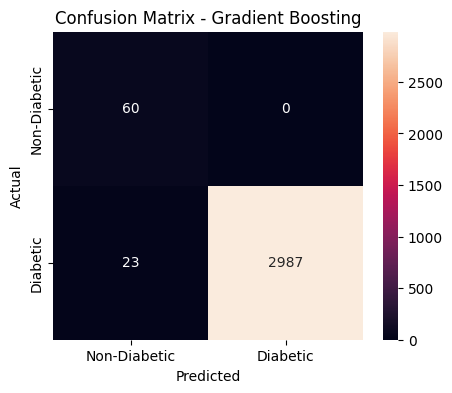

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

60 Non-Diabetic patients were correctly predicted as Non-Diabetic.
0 Non-Diabetic patients were wrongly predicted as Diabetic.

2987 Diabetic patients were correctly predicted as Diabetic.
23 Diabetic patients were wrongly predicted as Non-Diabetic.

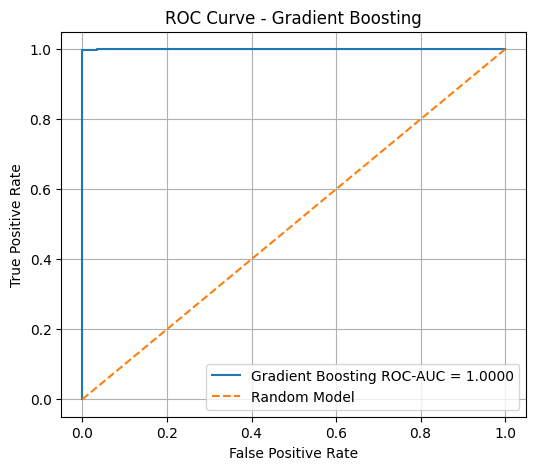

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model_2.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)


roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Gradient Boosting ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

plt.title('ROC Curve - Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

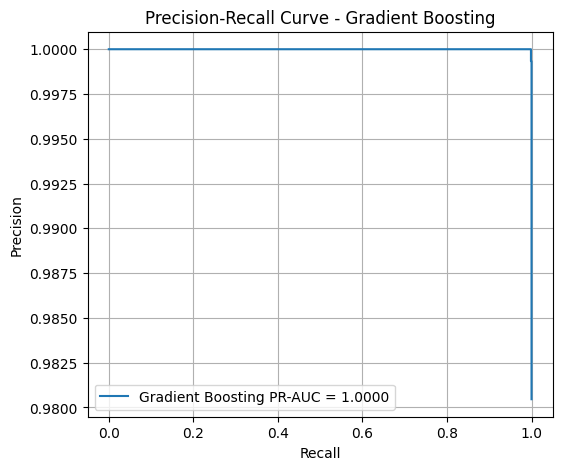

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Predicted probability for class 1 = Diabetic
y_proba = best_model_2.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Gradient Boosting PR-AUC = {pr_auc:.4f}')

plt.title('Precision-Recall Curve - Gradient Boosting')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

In [ ]:
feature_names = best_model_2.named_steps['preprocessor'].get_feature_names_out()

importances = best_model_2.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(30)

,Feature,Importance
4,num__Body Temperature,0.454365
2,num__Systolic Blood Pressure,0.178850
0,num__Age,0.116992
5,num__SPO2,0.074568
14,cat__Age_Group_Adult,0.052944
21,bin__Sweating (Y/N),0.048674
22,bin__Shivering (Y/N),0.022661
8,num__Symptom_Count,0.022257
3,num__Heart Rate,0.012792
7,num__MAP,0.007541


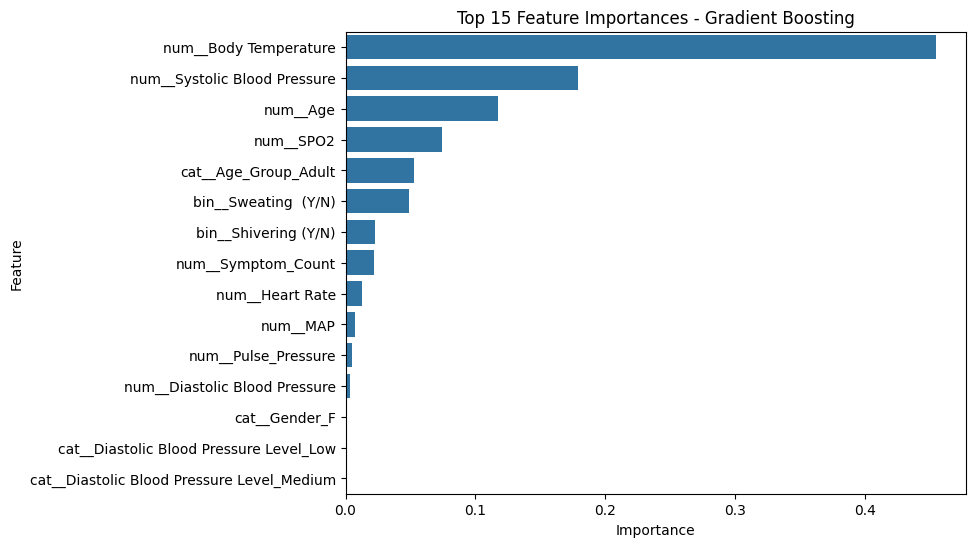

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15
                                    )
)

plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
import joblib

joblib.dump(best_model_2, 'diabetes_non_diabetes_pipeline_2.pkl')
print("Saved pipeline: diabetes_non_diabetes_pipeline_2.pkl")

Saved pipeline: diabetes_non_diabetes_pipeline_2.pkl


In [ ]:
sample = X_test.iloc[[0]]

prediction = best_model_2.predict(sample)[0]
probability = best_model_2.predict_proba(sample)[0]

print("Sample Data:")
display(sample)

print("Actual value:", y_test.iloc[0])
print("Predicted value:", prediction)

print("Probability of Non-Diabetic:", probability[0])
print("Probability of Diabetic:", probability[1])

if prediction == 1:
    print("Final Prediction: Diabetic")
else:
    print("Final Prediction: Non-Diabetic")

Sample Data:


,Age,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Body Temperature,SPO2,Pulse_Pressure,MAP,Symptom_Count,Gender,Diastolic Blood Pressure Level,Age_Group,HR_Category,Sweating (Y/N),Shivering (Y/N),Low_SPO2_Flag,Fever_Flag
5151,9.0,81.0,113.0,93.0,96.056328,98.0,32.0,91.666667,0,M,High,Child_Teen,Normal,0,0,0,0


Actual value: 1
Predicted value: 1
Probability of Non-Diabetic: 0.0014763962102033457
Probability of Diabetic: 0.9985236037897967
Final Prediction: Diabetic
